# Ship Detection — Sentinel-1 / Sentinel-2 Data Fusion

This notebook converts the Sentinel Hub
[Ship Detection (S1/S2)](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/ship_detection_s1_s2/)
evalscript by **Monja B. Šebela** into a reusable openEO User-Defined Process (UDP).

## Overview

Optical imagery alone cannot reliably separate a ship from sun glint or
whitecaps, and it is blocked by cloud. Radar alone cannot easily tell water
from land or other strong reflectors. This algorithm fuses both:

1. **Sentinel-2 (L1C)** — computes NDWI `(B03-B08)/(B03+B08)` to isolate
   water pixels.
2. **Sentinel-1 GRD (VV, VH)** — flags anomalously bright radar backscatter.
   Calm open water is a poor radar reflector (a flat surface bounces radar
   away from the sensor), so it looks dark in SAR. A metal hull acts like a
   corner reflector, producing a strong backscatter spike. "Water pixel with
   an anomalous radar return" is therefore a strong ship signal.

## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/ship_detection_s1_s2/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)

## Import Required Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rioxarray
from matplotlib.patches import Patch
from openeo.processes import and_, array_create, if_, or_

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

We connect to the **Copernicus Data Space Ecosystem (CDSE)**, the backend that
serves both Sentinel-1 GRD and Sentinel-2 L1C — both are required for the fusion.

This data-fusion algorithm needs a backend that serves BOTH Sentinel-1 GRD
and Sentinel-2 L1C. Keep the endpoint name in a variable so the Sentinel-1
collection/bands can be mapped through the SAME endpoint mapper below.

NOTE: ds_development's "sentinel-1-grd" collection was found to serve raw,
uncalibrated digital numbers (VV/VH in the 10s-to-10,000s), not calibrated
sigma0 backscatter. The diagnostic cell below would show even the minimum 
VV value trivially clearing the evalscript's 0.3 threshold. CDSE serves 
properly calibrated linear backscatter matching the original evalscript's 
units, so it's required for the fixed thresholds to be valid.

In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "ship_detection"

# Initialize parameter manager
param_manager = ParameterManager("ship_detection.params.py")

# Display available options using the built-in helper
param_manager.print_options("ship detection (S1/S2 fusion) algorithm")

Available parameter sets for ship detection (S1/S2 fusion) algorithm:
  1. zhenjiang_yangtze_river: Zhenjiang, Yangtze River
  2. singapore_strait: Singapore Strait anchorage
  3. sunda_strait_indonesia: Sunda Strait, Indonesia

Available OpenEO endpoints:
  1. localhost_dev: http://localhost:8082/
  2. ds_development: https://openeo.ds.io/
  3. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  4. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
endpoint_name = "copernicus_dataspace"
connection, current_params = param_manager.quick_connect(
    param_set="zhenjiang_yangtze_river",
    endpoint=endpoint_name,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: zhenjiang_yangtze_river
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Zhenjiang, Yangtze River
🔄 Parameters mapped for endpoint copernicus_dataspace:
  bands: ['b02', 'b03', 'b04', 'b08'] -> ['B02', 'B03', 'B04', 'B08']
  collection: sentinel-2-l1c -> SENTINEL2_L1C


## Load the Two Acquisitions

The algorithm fuses one Sentinel-2 (L1C) scene with one Sentinel-1 (GRD) scene.
The **Sentinel-2** collection/bands flow through the standard parameter mapping; the
**Sentinel-1** collection/bands are mapped explicitly through the same
endpoint's mapper.

The original evalscript uses `mosaicking: "ORBIT"` for both datasources —
each `evaluatePixel` call sees a single orbit/pass, not a temporal composite.
We reproduce that with the `first` reducer over a short `time` window (rather
than `mean`), since averaging across days would smear out the transient radar
signature that a moving vessel produces.

In [4]:
bbox = current_params["bounding_box"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]

# --- Sentinel-2 (L1C) optical ---
s2 = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=current_params["time"],
    spatial_extent=bbox,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"].default,
    },
).reduce_dimension(dimension=time_dim, reducer="first")
s2 = s2.resample_spatial(resolution=50, method="near")

# --- Sentinel-1 (GRD) SAR ---
_s1 = param_manager.apply_endpoint_mapping(
    {
        "collection": current_params["s1_collection"],
        "bands": current_params["s1_bands"],
    },
    endpoint_name,
)

s1 = connection.load_collection(
    _s1["collection"].default,
    temporal_extent=current_params["time"],
    spatial_extent=bbox,
    bands=_s1["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="first")
s1 = s1.resample_spatial(resolution=50, method="near")

print("Loaded S2 (L1C) and S1 (GRD), both resampled to 100m")

Loaded S2 (L1C) and S1 (GRD), both resampled to 100m


## Fuse the Sensors into One Cube

Both cubes carry distinctly-named bands (`b02/b03/b04/b08` vs `vv/vh`), so
there is no label collision and no `add_dimension` relabeling is needed.
We only need to align the two grids before merging.

In [5]:
s1_aligned = s1.resample_cube_spatial(s2, method="near")
fused = s2.merge_cubes(s1_aligned)

# The classification reads bands positionally; the order is fixed by
# construction: the 4 Sentinel-2 bands (load order) followed by vv, vh.
fused_bands = fused.metadata.band_names
print("Fused band order:", fused_bands)
assert len(fused_bands) == 6, f"expected 6 fused bands, got {fused_bands}"

Fused band order: ['B02', 'B03', 'B04', 'B08', 'VV', 'VH']


### Diagnostic: check actual band value ranges before trusting the thresholds

The `NDWI > 0.1` and `VV/VH > 0.3` thresholds are copied from the Sentinel Hub
evalscript, which assumes Sentinel Hub's own calibrated sigma0 backscatter
convention. If this backend's `sentinel-1-grd` collection returns VV/VH in a
different unit (raw digital numbers, a different sigma0 scaling, or dB), the
`0.3` threshold can be trivially satisfied almost everywhere over water.

Download a small preview and print percentiles for both sensors before relying
on the fixed thresholds.

In [6]:
_diag_job = param_manager.resolve(fused, current_params).create_job(
    title="ship_detection_diagnostic",
    out_format="GTiff",
)
_diag_job.start_and_wait()

_diag_dir = Path(f"{_algorithm_id}_diagnostic_results")
_diag_dir.mkdir(exist_ok=True)
_diag_job.get_results().download_files(_diag_dir)
_diag_path = next(_diag_dir.glob("*.tif"))

0:00:00 Job 'j-26080614093242fa841cac3c00bbf5bd': send 'start'
0:00:03 Job 'j-26080614093242fa841cac3c00bbf5bd': created (progress 0%)
0:00:09 Job 'j-26080614093242fa841cac3c00bbf5bd': queued (progress 0%)
0:00:15 Job 'j-26080614093242fa841cac3c00bbf5bd': queued (progress 0%)
0:00:23 Job 'j-26080614093242fa841cac3c00bbf5bd': queued (progress 0%)
0:00:33 Job 'j-26080614093242fa841cac3c00bbf5bd': queued (progress 0%)
0:00:45 Job 'j-26080614093242fa841cac3c00bbf5bd': running (progress N/A)
0:01:01 Job 'j-26080614093242fa841cac3c00bbf5bd': running (progress N/A)
0:01:20 Job 'j-26080614093242fa841cac3c00bbf5bd': running (progress N/A)
0:01:44 Job 'j-26080614093242fa841cac3c00bbf5bd': running (progress N/A)
0:02:14 Job 'j-26080614093242fa841cac3c00bbf5bd': running (progress N/A)
0:02:52 Job 'j-26080614093242fa841cac3c00bbf5bd': running (progress N/A)
0:03:38 Job 'j-26080614093242fa841cac3c00bbf5bd': running (progress N/A)
0:04:37 Job 'j-26080614093242fa841cac3c00bbf5bd': finished (progress 1

In [7]:
_diag_ds = rioxarray.open_rasterio(_diag_path)
for _i, _name in enumerate(fused.metadata.band_names):
    _band_vals = _diag_ds.isel(band=_i).values
    print(
        f"{_name:>6}: min={np.nanmin(_band_vals):.4f}  "
        f"p50={np.nanpercentile(_band_vals, 50):.4f}  "
        f"p99={np.nanpercentile(_band_vals, 99):.4f}  "
        f"max={np.nanmax(_band_vals):.4f}"
    )

   B02: min=888.0000  p50=1349.0000  p99=2128.0000  max=7462.0000
   B03: min=792.0000  p50=1231.0000  p99=1995.0000  max=8805.0000
   B04: min=643.0000  p50=1066.0000  p99=2133.0000  max=13044.0000
   B08: min=551.0000  p50=1746.0000  p99=4226.0000  max=18006.0000
    VV: min=0.0002  p50=0.0898  p99=4.0799  max=1119.3470
    VH: min=0.0000  p50=0.0177  p99=0.3974  max=78.2582


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


## Per-Pixel Classification

A single `apply_dimension` over the bands dimension runs the original
`evaluatePixel` logic. The callback receives the 6 fused band values (S2's
`b02, b03, b04, b08` followed by S1's `vv, vh`) and returns the 3-element
`[R, G, B]` output.

Faithful to the original:

- `NDWI = (b03 - b08) / (b03 + b08)`, water where `NDWI > 0.1`.
- Sentinel-2 reflectance is divided by `reflectance_scale` (10000 on CDSE) to
  match the original's 0-1 input range; Sentinel-1 backscatter is used as-is
  (linear), matching the original's `VV`/`VH` thresholds.
- `red` and `green` use the same formula (`4*b04-0.2`, `4*b03-0.2`) in every
  branch; only `blue` differs — water gets a `5*b02-0.2` boost (pushing water
  slightly bluer for context), land gets `4*b02-0.2`. Ship pixels override
  all three channels to pure white `[1, 1, 1]`.

In [8]:
scale = current_params["reflectance_scale"]  # 10000.0 on CDSE

# Original classification thresholds.
THR_NDWI = 0.1  # NDWI above this == water
THR_SAR = 0.3  # VV or VH above this over water == anomalous reflector (ship)


def classify(data):
    # Bands in fused order: b02, b03, b04, b08 (S2), then vv, vh (S1).
    b02 = data[0] / scale
    b03 = data[1] / scale
    b04 = data[2] / scale
    b08 = data[3] / scale
    vv = data[4]
    vh = data[5]

    ndwi = (b03 - b08) / (b03 + b08)
    is_water = ndwi > THR_NDWI
    is_ship = and_(is_water, or_(vv > THR_SAR, vh > THR_SAR))

    red = (4 * b04) - 0.2
    green = (4 * b03) - 0.2
    blue_water = (5 * b02) - 0.2
    blue_land = (4 * b02) - 0.2

    out_red = if_(is_ship, 1.0, red)
    out_green = if_(is_ship, 1.0, green)
    out_blue = if_(is_ship, 1.0, if_(is_water, blue_water, blue_land))

    return array_create([out_red, out_green, out_blue])


rgb = fused.apply_dimension(dimension=bands_dim, process=classify)

## Apply and Export

Save the 3-band classification/visualization as a GeoTIFF.

In [9]:
ship_result = rgb.save_result("GTiff")

## Download and Visualize Results

Download the composite and display it directly as an RGB image — detected
ships render as pure white against the enhanced-color background.

In [10]:
# Synchronous execution (POST /result) does not accept unresolved Parameter
# refs, so materialize them with the current parameter set's defaults before
# download.
filename = f"{_algorithm_id}_{current_params['location_name'].replace(' ', '_').replace(',', '').replace('/', '-').lower()}.tif"

resolved = param_manager.resolve(ship_result, current_params)
resolved.download(filename)

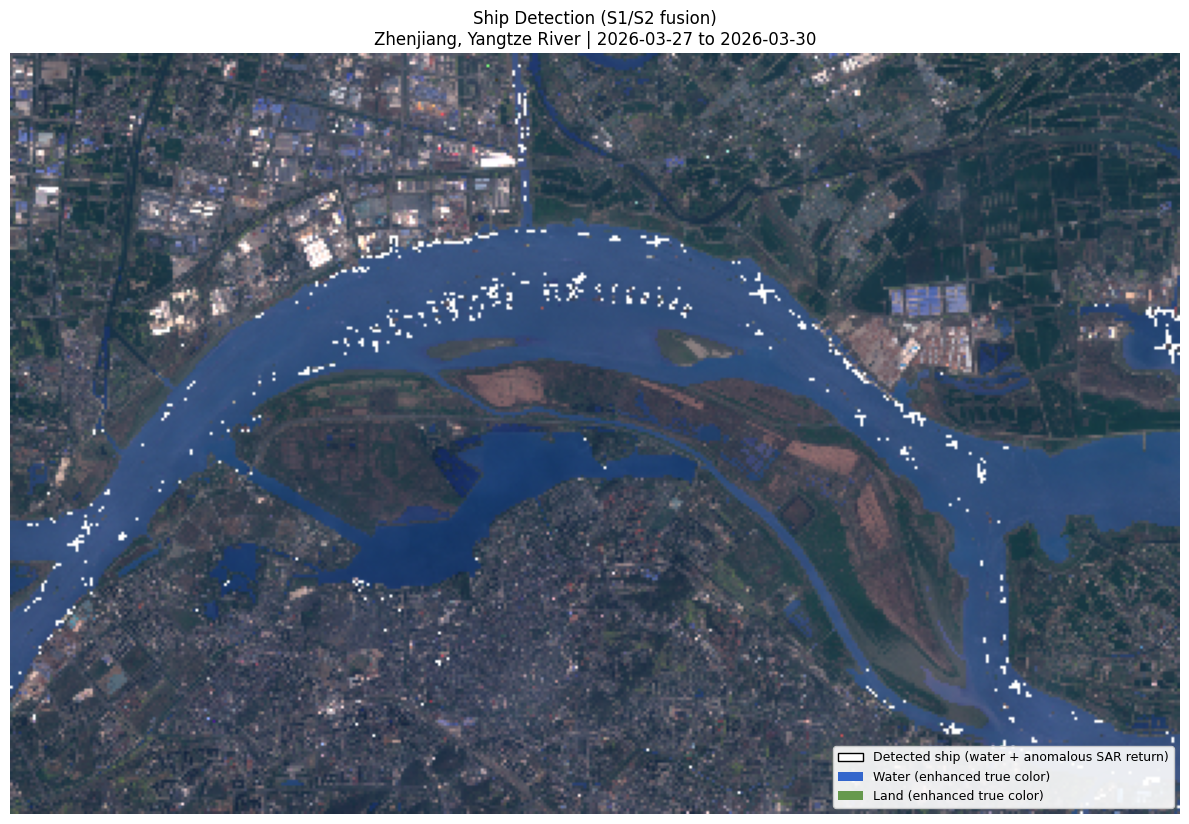

In [11]:
# Open the 3-band result and display it as an RGB image.
ds = rioxarray.open_rasterio(filename)

rgb_img = ds.transpose("y", "x", "band").values.astype("float32")
rgb_img = np.clip(rgb_img, 0, 1)

preview_fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(
    rgb_img,
    extent=[ds.x.values.min(), ds.x.values.max(), ds.y.values.min(), ds.y.values.max()],
)
ax.set_title(
    f"Ship Detection (S1/S2 fusion)\n{current_params['location_name']} | "
    f"{current_params['time'].default[0]} to {current_params['time'].default[1]}",
    fontsize=12,
)

legend = [
    Patch(
        facecolor=(1, 1, 1),
        edgecolor="black",
        label="Detected ship (water + anomalous SAR return)",
    ),
    Patch(facecolor=(0.2, 0.4, 0.8), label="Water (enhanced true color)"),
    Patch(facecolor=(0.4, 0.6, 0.3), label="Land (enhanced true color)"),
]
ax.legend(handles=legend, loc="lower right", fontsize=9, framealpha=0.9)
ax.axis("off")
plt.tight_layout()

plt.show()

## Interpretation Guide and Limitations

### Reading the result

- **White** pixels are the key output: water where the radar backscatter
  spikes above the calm-sea baseline in either polarization — the ship
  detections.
- The tinted **blue-shifted water** and **true-color land** are context only,
  reproducing the original's enhanced RGB stretch.

### Limitations and differences from the original

- **CDSE required, not just recommended.** The fusion needs both Sentinel-1
  GRD and Sentinel-2 L1C, but more importantly: the fixed `VV`/`VH > 0.3`
  threshold only holds on backends that serve **calibrated linear sigma0
  backscatter**, matching Sentinel Hub's convention. 
  
  A diagnostic run against
  `ds_development` showed its `sentinel-1-grd` collection returns raw,
  uncalibrated digital numbers (VV/VH ranging 10-38,000, with even the
  *minimum* value far exceeding `0.3`) rather than calibrated backscatter —
  every water pixel trivially cleared the threshold, misclassifying the
  entire river as "ship" (white). 
  
  CDSE's `sentinel-1-grd` was confirmed to
  serve properly calibrated linear backscatter, so it's required for this
  notebook's fixed thresholds to be meaningful
  
  If a future backend also serves raw DN, the thresholds would need to be 
  adapted to the data distribution, instead of the fixed `0.3`.

- **Not simultaneous.** Like the original's `mosaicking: "ORBIT"`, this picks
  one S1 pass and one S2 pass inside the same short `time` window rather than
  a truly coincident acquisition — a ship may have moved between the two
  passes, or be present in one image and not the other.

- **Known false positives/negatives (per the original author):** narrow
  waterways and bridges can trigger false positives (structures reflect radar
  strongly, similar to hulls); red-hulled vessels tend to be under-detected.

- **No cloud masking on S2.** The single-pass NDWI is assumed to see a clear
  water surface; heavy cloud over the scene would corrupt the water mask.

- **Grid alignment.** S1 is resampled onto the S2 grid with
  nearest-neighbour before merging; minor co-registration differences between
  sensors are not corrected.

- **Validated so far against `copernicus_dataspace` and `ds_development`.** 
  The run on `ds_development` surfaced the raw-DN issue above; the notebook 
  has been re-run end-to-end against CDSE.

## Validation: Testing Across Additional Locations

The algorithm is re-run against the two other ship-traffic parameter sets: 
the **Singapore Strait** anchorage and the **Sunda Strait** ferry/shipping
chokepoint between Java and Sumatra, Indonesia, in addition to the Zhenjiang
run above. 

The pipeline above (connect → load S2/S1 → resample to 50m → fuse → classify
→ `save_result`) is wrapped into a function so it can be re-run per parameter
set without duplicating the cells, and submitted as a sync job via `.download()`

In [10]:
validation_sets = ["singapore_strait", "sunda_strait_indonesia"]
validation_outputs = {}

for set_name in validation_sets:
    param_manager.use_parameter_set(set_name)
    val_raw_params = param_manager.get_parameter_set()
    val_params = param_manager.apply_endpoint_mapping(val_raw_params, endpoint_name)

    val_bbox = val_params["bounding_box"]
    val_bands_dim = val_params["bands_dimension"]
    val_time_dim = val_params["time_dimension"]
    val_cloud_cover = val_params["cloud_cover"].default

    val_s2 = connection.load_collection(
        val_params["collection"].default,
        temporal_extent=val_params["time"],
        spatial_extent=val_bbox,
        bands=val_params["bands"].default,
        properties={"eo:cloud_cover": lambda x, t=val_cloud_cover: x <= t},
    ).reduce_dimension(dimension=val_time_dim, reducer="first")
    val_s2 = val_s2.resample_spatial(resolution=50, method="near")

    val_s1_map = param_manager.apply_endpoint_mapping(
        {"collection": val_params["s1_collection"], "bands": val_params["s1_bands"]},
        endpoint_name,
    )
    val_s1 = connection.load_collection(
        val_s1_map["collection"].default,
        temporal_extent=val_params["time"],
        spatial_extent=val_bbox,
        bands=val_s1_map["bands"].default,
    ).reduce_dimension(dimension=val_time_dim, reducer="first")
    val_s1 = val_s1.resample_spatial(resolution=50, method="near")

    val_fused = val_s2.merge_cubes(val_s1.resample_cube_spatial(val_s2, method="near"))

    val_rgb = val_fused.apply_dimension(dimension=val_bands_dim, process=classify)
    val_result = val_rgb.save_result("GTiff")

    val_file = f"{_algorithm_id}_{set_name}.tif"
    val_job = param_manager.resolve(val_result, val_params).download(val_file)
    validation_outputs[set_name] = (val_file, val_params)
    print(f"✅ {set_name}: {val_file}")

# Restore the primary parameter set for the export section below.
param_manager.use_parameter_set("zhenjiang_yangtze_river")

✅ singapore_strait: ship_detection_singapore_strait.tif
✅ sunda_strait_indonesia: ship_detection_sunda_strait_indonesia.tif


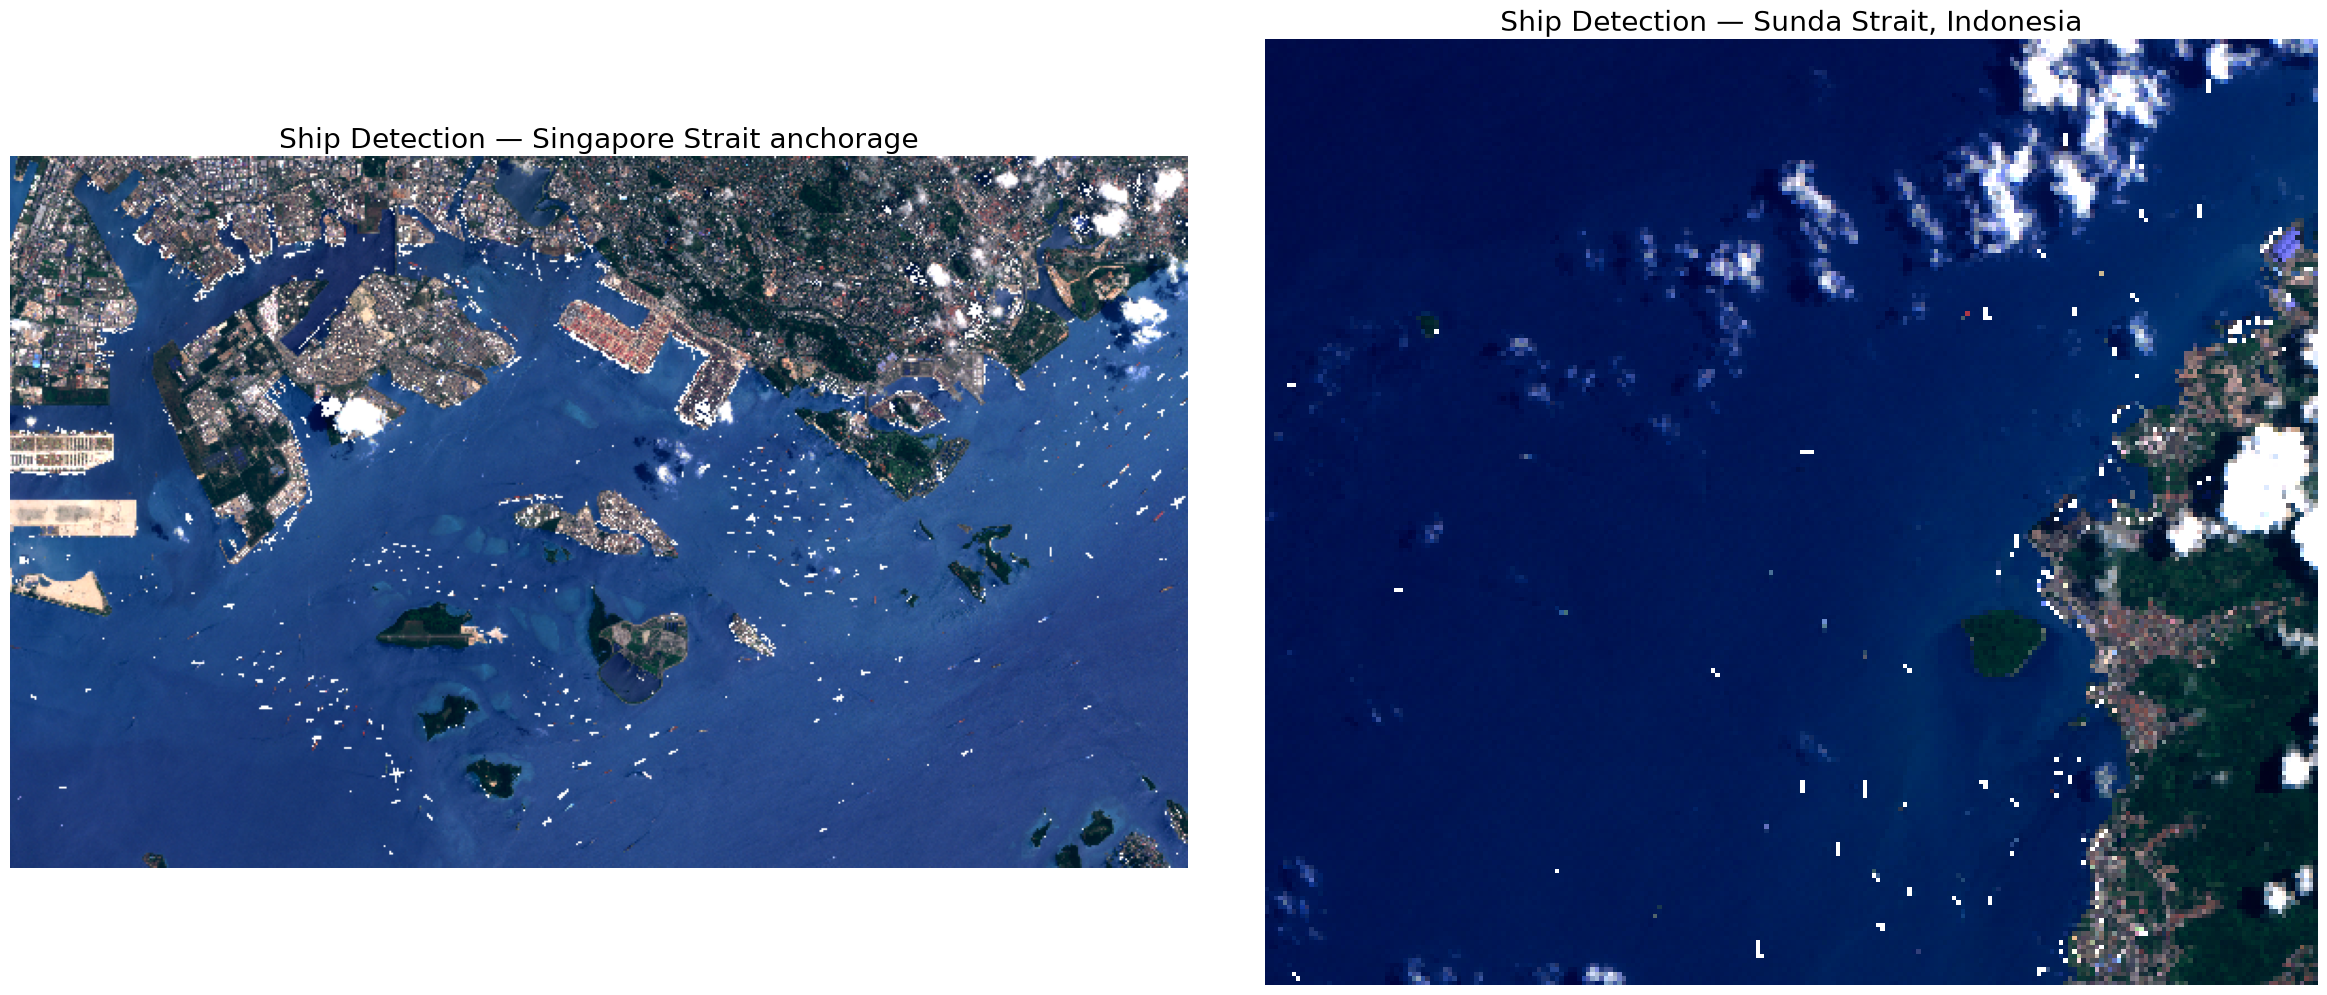

In [11]:
validation_fig, axes = plt.subplots(
    1, len(validation_sets), figsize=(12 * len(validation_sets), 10), dpi=100
)

for ax, set_name in zip(axes, validation_sets, strict=True):
    val_file, val_params = validation_outputs[set_name]
    val_ds = rioxarray.open_rasterio(val_file)
    val_img = np.clip(val_ds.transpose("y", "x", "band").values.astype("float32"), 0, 1)
    ax.imshow(val_img)
    ax.set_title(f"Ship Detection — {val_params['location_name']}", fontsize=20)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Export as a Reusable openEO Process

Export the parameterized process graph and an APEx catalogue record so the
algorithm can be registered and reused.

In [12]:
# Export necessary metadata to register the process graph in APEx Algorithm Catalogue
from pathlib import Path

from openeo_udp import ParameterManager
from openeo_udp.endpoints import get_endpoint_config

_algorithm_id = "ship_detection"

_repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "notebooks").exists()
)
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

_param_set = "zhenjiang_yangtze_river"
_endpoint_name = "copernicus_dataspace"
_param_manager = ParameterManager(f"{_algorithm_id}.params.py")
_raw_params = _param_manager.get_parameter_set(_param_set)

# Endpoint mapping resolves the backend-native collection id (which can differ from
# the canonical id in ship_detection.params.py), matching what the earlier cells
# actually load via quick_connect().
_mapped_params = _param_manager.apply_endpoint_mapping(_raw_params, _endpoint_name)
_endpoint_config = get_endpoint_config(_endpoint_name)

# Notebook metadata
metadata = {
    "id": _algorithm_id,
    "title": "Ship Detection (S1/S2 Fusion)",
    "preview_title": "Ship Detection (S1/S2 Fusion)",
    "description": (
        "Sentinel-1 / Sentinel-2 data fusion that detects ships at sea by combining "
        "a Sentinel-2 NDWI water mask with anomalously bright Sentinel-1 VV/VH "
        "backscatter returns over water."
    ),
    "keywords": [
        "Radar",
        "Sentinel-1",
        "Sentinel-2",
    ],
    "themes": [
        "MARINE MONITORING",
        "MARITIME SURVEILLANCE",
        "REMOTE SENSING",
        "Sentinel-1 SAR",
        "Sentinel-2 MSI",
    ],
    "created": "2026-07-30T00:00:00Z",
    "updated": "2026-07-30T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": _endpoint_config["name"],
    "openeo_backend_url": _endpoint_config["url"],
    "notebook_github_location": _nb_href,
    "collection_id": _mapped_params["collection"].default,
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/ship_detection_s1_s2/",
        "authors": ["Monja B. Sebela"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": None,
    },
}

In [13]:
# Export the process graph for reuse
import json

from algorithm_registration.register_algorithm import register

process_graph = {
    "process_graph": ship_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Sentinel-1/Sentinel-2 data-fusion ship detection using openEO.",
    "description": metadata["description"],
}

# Save the process graph
udp_path = Path(f"{_algorithm_id}.json")
with open(udp_path, "w") as f:
    json.dump(process_graph, f, indent=2)

register(
    notebook_path=Path.cwd() / f"{_algorithm_id}.ipynb",
    udp_path=Path(f"{_algorithm_id}.json"),
    preview_fig=preview_fig,
)

Algorithm directory: algorithm_registration/ship_detection
UDP registered: algorithm_registration/ship_detection/openeo_udp/ship_detection.json
Preview registered from figure: algorithm_registration/ship_detection/records/preview.png
Record written: algorithm_registration/ship_detection/records/ship_detection.json
Thumbnail written: algorithm_registration/ship_detection/records/thumbnail.png
Commit all the records before pushing to openeo-udp repository


PosixPath('algorithm_registration/ship_detection')

## References and Attribution

**Original Script:** [Ship Detection (S1/S2)](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/ship_detection_s1_s2/)

**Author:** Monja B. Šebela

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### openEO Conversion
- **Conversion Date**: 30 July 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
  ([processes.openeo.org](https://processes.openeo.org/))
- **Backend Targeted**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the Ship Detection (S1/S2) algorithm into an openEO
User-Defined Process. The implementation:

- **Fuses two sensors** (S2 L1C, S1 GRD) using `resample_cube_spatial` for grid
  alignment and `merge_cubes`.
- **Reproduces the per-pixel classification** with nested `if_`/`and_`/`or_`,
  preserving the original NDWI and SAR thresholds.
- **Follows the repository's UDP conventions** with a parameterized process
  graph, three example locations with heavy ship traffic, and catalogue
  metadata scaffolding.

### Key conversion notes
- `bounding_box`, `time`, and `cloud_cover` are the UDP parameters; collections
  and bands are intrinsic to the algorithm.
- Targets CDSE because it serves both Sentinel-1 GRD and Sentinel-2 L1C.
- Three parameter sets are provided, each a documented ship-traffic hotspot:
  Zhenjiang on the Yangtze River, the Singapore Strait, and the Sunda Strait
  ferry/shipping chokepoint between Java and Sumatra, Indonesia.